In [2]:
import ray
import ray.data

s3_uri = "s3://anonymous@air-example-data-2/imagenette2/train/"

ds = ray.data.read_images(s3_uri, mode="RGB")
ds

Dataset(num_rows=9469, schema=Unknown schema)

In [3]:
ds.schema()

2026-02-20 15:25:37,895	INFO logging.py:392 -- Registered dataset logger for dataset dataset_6_0
2026-02-20 15:25:37,920	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_6_0. Full logs are in /tmp/ray/session_2026-02-20_15-25-00_384845_911/logs/ray-data
2026-02-20 15:25:37,920	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_6_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadImage] -> LimitOperator[limit=1]
2026-02-20 15:25:38,106	WARNING resource_manager.py:141 -- ⚠️  Ray's object store is configured to use only 42.9% of available memory (8.6GiB out of 20.2GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.
2026-02-20 15:25:38,109	INFO __init__.py:56 -- Progress will be logged because stdout is a non-inte

Column  Type
------  ----
image   ArrowVariableShapedTensorType(ndim=3, dtype=uint8)

In [4]:
single_batch = ds.take_batch(10)

2026-02-20 15:26:14,757	INFO logging.py:392 -- Registered dataset logger for dataset dataset_7_0
2026-02-20 15:26:14,769	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_7_0. Full logs are in /tmp/ray/session_2026-02-20_15-25-00_384845_911/logs/ray-data
2026-02-20 15:26:14,769	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_7_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadImage] -> LimitOperator[limit=10]
2026-02-20 15:26:15,046	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_7_0 =======
2026-02-20 15:26:15,047	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-02-20 15:26:15,048	INFO logging_progress.py:227 -- Active & requested resources: 0/12 CPU, 0.0B/4.3GiB object store
2026-02-20 15:26:15,049	INFO logging_progress.py:181 -- 
2026-02-20 15:26:15,049	INFO logging_progress.py:231 -- ReadImage: 0/1
2026-02-20 15:26:15,051	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 199 (0.0B); Resources:

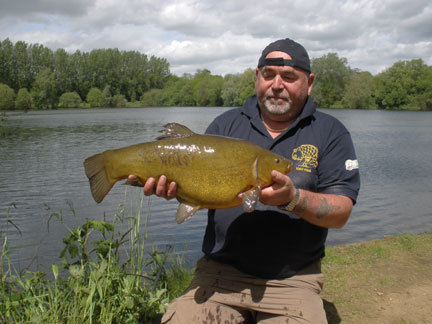

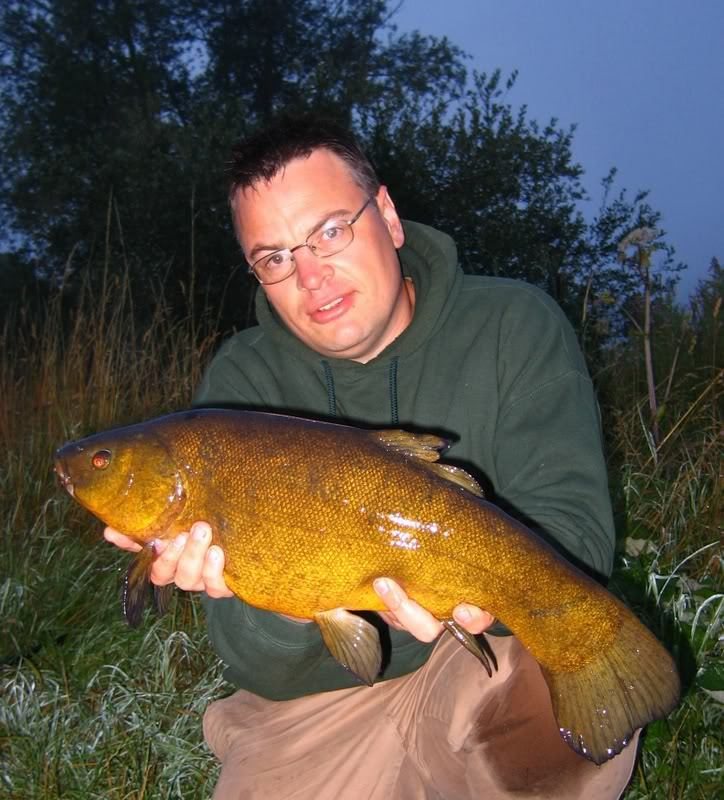

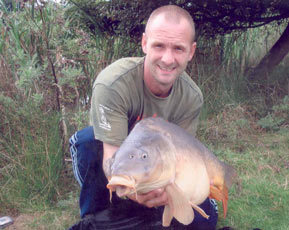

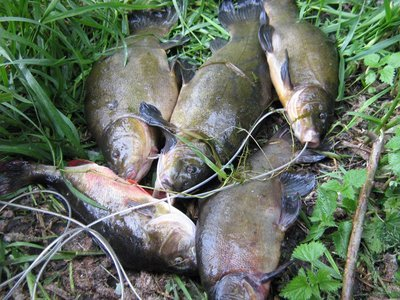

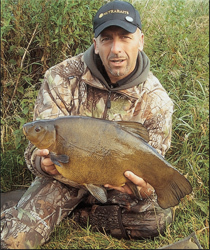

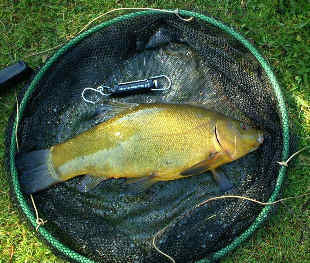

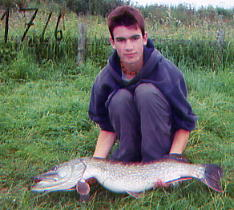

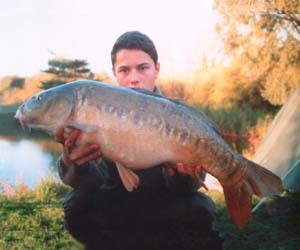

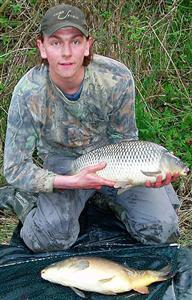

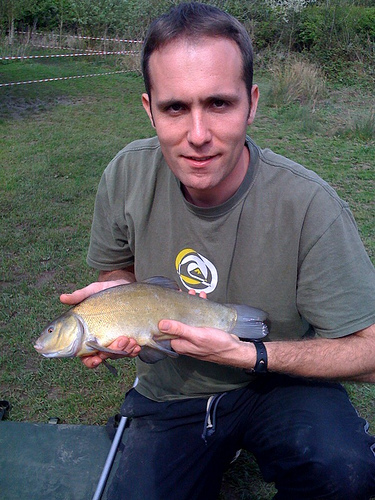

In [14]:
from PIL import Image
for picture in single_batch["image"]:
    img = Image.fromarray(picture)
    img.show()

In [15]:
import torch
from torchvision.models import ResNet152_Weights
from torchvision import transforms
from torchvision import models

weights = ResNet152_Weights.IMAGENET1K_V1

# Load the pretrained resnet model and move to GPU if one is available.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet152(weights=weights).to(device)
model.eval()

imagenet_transforms = weights.transforms
transform = transforms.Compose([transforms.ToTensor(), imagenet_transforms()])

3.8%

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100.0%


In [16]:
transformed_batch = [transform(image) for image in single_batch["image"]]
with torch.inference_mode():
    prediction_results = model(torch.stack(transformed_batch).to(device))
    classes = prediction_results.argmax(dim=1).cpu()

del model  # Free up GPU memory

labels = [weights.meta["categories"][i] for i in classes]
labels

['tench',
 'tench',
 'tench',
 'tench',
 'tench',
 'tench',
 'barracouta',
 'tench',
 'tench',
 'tench']

In [17]:
import numpy as np
from typing import Dict

def preprocess_image(row: Dict[str, np.ndarray]):
    return {
        "original_image": row["image"],
        "transformed_image": transform(row["image"]),
    }

In [18]:
transformed_ds = ds.map(preprocess_image)

In [19]:
from typing import Dict
import numpy as np
import torch


class ResnetModel:
    def __init__(self):
        self.weights = ResNet152_Weights.IMAGENET1K_V1
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = models.resnet152(weights=self.weights).to(self.device)
        self.model.eval()

    def __call__(self, batch: Dict[str, np.ndarray]):
        # Convert the numpy array of images into a PyTorch tensor.
        # Move the tensor batch to GPU if available.
        torch_batch = torch.from_numpy(batch["transformed_image"]).to(self.device)
        with torch.inference_mode():
            prediction = self.model(torch_batch)
            predicted_classes = prediction.argmax(dim=1).detach().cpu()
            predicted_labels = [
                self.weights.meta["categories"][i] for i in predicted_classes
            ]
            return {
                "predicted_label": predicted_labels,
                "original_image": batch["original_image"],
            }

In [20]:
predictions = transformed_ds.map_batches(
    ResnetModel,
    compute=ray.data.ActorPoolStrategy(size=4),  # Use 4 GPUs. Change this number based on the number of GPUs in your cluster.
    num_gpus=1,  # Specify 1 GPU per model replica.
    batch_size=720,  # Use the largest batch size that can fit on our GPUs.
)

In [22]:
prediction_batch = predictions.take_batch(5)

2026-02-20 15:46:50,642	INFO logging.py:392 -- Registered dataset logger for dataset dataset_10_0
2026-02-20 15:46:50,663	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_10_0. Full logs are in /tmp/ray/session_2026-02-20_15-25-00_384845_911/logs/ray-data
2026-02-20 15:46:50,664	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_10_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadImage->Map(preprocess_image)] -> ActorPoolMapOperator[MapBatches(ResnetModel)] -> LimitOperator[limit=5]
2026-02-20 15:46:51,064	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_10_0 =======
2026-02-20 15:46:51,065	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-02-20 15:46:51,065	INFO logging_progress.py:227 -- Active & requested resources: 0/12 CPU, 0.0B/4.3GiB object store (pending: 4 GPU)
2026-02-20 15:46:51,066	INFO logging_progress.py:181 -- 
2026-02-20 15:46:51,067	INFO logging_progress.py:231 -- ReadImage->Map(preprocess_image): 0/1
2

(autoscaler +21m54s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.
(autoscaler +21m54s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


(ReadImage->Map(preprocess_image) pid=1201) /usr/local/lib/python3.13/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
(ReadImage->Map(preprocess_image) pid=1201)   img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
2026-02-20 15:47:01,079	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_10_0 =======
2026-02-20 15:47:01,080	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-02-20 15:47:01,081	INFO logging_progress.py:227 -- Active & requested resources: 12/12 CPU, 1.0GiB/4.3GiB object store (pending: 4 GPU)
2026-02-20 15:47:01,082	IN

(autoscaler +22m29s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


2026-02-20 15:47:31,225	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_10_0 =======
2026-02-20 15:47:31,226	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-02-20 15:47:31,227	INFO logging_progress.py:227 -- Active & requested resources: 1/12 CPU, 3.7GiB/4.3GiB object store (pending: 4 GPU)
2026-02-20 15:47:31,228	INFO logging_progress.py:181 -- 
2026-02-20 15:47:31,229	INFO logging_progress.py:231 -- ReadImage->Map(preprocess_image): 3264/9600
2026-02-20 15:47:31,230	INFO logging_progress.py:233 --   Tasks: 1 [backpressured:tasks(ResourceBudget)]; Actors: 0; Queued blocks: 131 (0.0B); Resources: 1.0 CPU, 3.7GiB object store
2026-02-20 15:47:31,231	INFO logging_progress.py:231 -- MapBatches(ResnetModel): 0/1
2026-02-20 15:47:31,232	INFO logging_progress.py:233 --   Tasks: 0 [backpressured:tasks(ResourceBudget)]; Actors: 4 (running=0, restarting=0, pending=4); Queued blocks: 69 (3.7GiB); Resources: 0.0 CPU, 0.0B object store; [all objects local]
2026-02-20 15:4

(autoscaler +23m4s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


(raylet) [2026-02-20 15:48:08,364 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.747684 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
2026-02-20 15:48:11,385	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_10_0 =======
2026-02-20 15:48:11,385	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-02-20 15:48:11,387	INFO logging_progress.py:227 -- Active & requested resources: 1/12 CPU, 4.0GiB/4.3GiB object store (pending: 4 GPU)
2026-02-20 15:48:11,388	INFO logging_progress.py:181 -- 
2026-02-20 15:48:11,389	INFO logging_progress.py:231 -- ReadImage->Map(preprocess_image): 3547/9586
2026-02-20 15:48:11,391	INFO logging_progress.py:233 --   Tasks: 1 [backpressured:tasks(ResourceBudget)]; Actors: 0; Queued blocks: 125 (0.0B); Resources: 1.0 CPU, 4.0GiB object store
2026-02-20 15:48:11,392	INFO logging_progress.py:231 -- MapBatches(ResnetModel): 0/1
202

(autoscaler +23m39s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


2026-02-20 15:48:41,586	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_10_0 =======
2026-02-20 15:48:41,588	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-02-20 15:48:41,589	INFO logging_progress.py:227 -- Active & requested resources: 1/12 CPU, 4.2GiB/4.3GiB object store (pending: 4 GPU)
2026-02-20 15:48:41,590	INFO logging_progress.py:181 -- 
2026-02-20 15:48:41,590	INFO logging_progress.py:231 -- ReadImage->Map(preprocess_image): 3735/9577
2026-02-20 15:48:41,591	INFO logging_progress.py:233 --   Tasks: 1 [backpressured:tasks(ResourceBudget)]; Actors: 0; Queued blocks: 121 (0.0B); Resources: 1.0 CPU, 4.2GiB object store
2026-02-20 15:48:41,592	INFO logging_progress.py:231 -- MapBatches(ResnetModel): 0/1
2026-02-20 15:48:41,593	INFO logging_progress.py:233 --   Tasks: 0 [backpressured:tasks(ResourceBudget)]; Actors: 4 (running=0, restarting=0, pending=4); Queued blocks: 79 (4.2GiB); Resources: 0.0 CPU, 0.0B object store; [all objects local]
2026-02-20 15:4

RayTaskError(OutOfDiskError): [36mray::ReadImage->Map(preprocess_image)()[39m (pid=1990, ip=172.17.0.2)
  File "python/ray/includes/common.pxi", line 100, in ray._raylet.check_status
ray.exceptions.OutOfDiskError: Local disk is full
The object cannot be created because the local object store is full and the local disk's utilization is over capacity (95% by default).Tip: Use `df` on this node to check disk usage and `ray memory` to check object store memory usage.

In [ ]:
from PIL import Image

for image, prediction in zip(
    prediction_batch["original_image"], prediction_batch["predicted_label"]
):
    img = Image.fromarray(image)
    display(img)
    print("Prediction: ", prediction)

(autoscaler +24m14s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


(raylet) [2026-02-20 15:49:18,496 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.310085 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:49:28,518 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.310085 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:49:38,537 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.310081 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:49:48,556 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.310059 GB; capacity: 20.6177 GB. Object creation will fail if spilling i

(autoscaler +24m50s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


(raylet) [2026-02-20 15:49:58,578 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.310051 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:50:08,595 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.309868 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:50:18,611 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.309769 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.


(autoscaler +25m25s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.


(raylet) [2026-02-20 15:50:28,627 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.309761 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:50:38,643 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.30975 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:50:48,660 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.309734 GB; capacity: 20.6177 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-20 15:50:58,676 E 1058 1084] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-20_15-25-00_384845_911 is over 95% full, available space: 0.309715 GB; capacity: 20.6177 GB. Object creation will fail if spilling is

(autoscaler +26m0s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.
(autoscaler +26m35s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.
(autoscaler +27m10s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.
(autoscaler +27m45s) Error: No available node types can fulfill resource request {'CPU': 1.0, 'GPU': 1.0}. Add suitable node types to this cluster to resolve this issue.
